In [1]:
import argparse
import os
import numpy as np
import math

import torchvision.transforms as transforms
from torchvision.utils import save_image
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets
from torch.autograd import Variable

import torch.nn as nn
import torch.nn.functional as F
import torch

In [2]:
os.makedirs("images", exist_ok=True)
n_epochs = 200
batch_size = 64
lr = 0.0002
b1 = 0.5
b2 = 0.999
n_cpu = 8
latent_dim = 128
n_classes = 10
img_size = 28
channels=1
sample_interval = 400

In [3]:
img_shape = (1,28,28)

cuda = True if torch.cuda.is_available() else False

Generator

In [4]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.label_emb = nn.Embedding(n_classes, n_classes)

        def block(in_feat, out_feat, normalize=True):
            layers = [nn.Linear(in_feat, out_feat)]
            if normalize:
                layers.append(nn.BatchNorm1d(out_feat, 0.8))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(latent_dim + n_classes, 128, normalize=False),
            *block(128, 256),
            *block(256, 512),
            *block(512, 1024),
            nn.Linear(1024, int(np.prod(img_shape))),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        # Concatenate label embedding and image to produce input
        gen_input = torch.cat((self.label_emb(labels), noise), -1)
        img = self.model(gen_input)
        img = img.view(img.size(0), *img_shape)
        return img

Discriminator

In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()

        self.label_embedding = nn.Embedding(n_classes, n_classes)

        self.model = nn.Sequential(
            nn.Linear(n_classes + int(np.prod(img_shape)), 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 512),
            nn.Dropout(0.4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 512),
            nn.Dropout(0.4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1),
        )

    def forward(self, img, labels):
        # Concatenate label embedding and image to produce input
        d_in = torch.cat((img.view(img.size(0), -1), self.label_embedding(labels)), -1)
        validity = self.model(d_in)
        return validity

In [6]:
# Loss functions
adversarial_loss = torch.nn.MSELoss()

# Initialize generator and discriminator
generator = Generator()
discriminator = Discriminator()

if cuda:
    generator.cuda()
    discriminator.cuda()
    adversarial_loss.cuda()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataloader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(
        './data',
        train=True,
        transform=transform,
        download=True
    ),
    batch_size=batch_size,
    shuffle=True
)

# Optimizers
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))

FloatTensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor
LongTensor = torch.cuda.LongTensor if cuda else torch.LongTensor


def sample_image(n_row, batches_done=None):
    """Saves a grid of generated digits ranging from 0 to n_classes"""
    # Sample noise
    z = Variable(FloatTensor(np.random.normal(0, 1, (n_row ** 2, latent_dim))))
    # Get labels ranging from 0 to n_classes for n rows
    labels = np.array([num for _ in range(n_row) for num in range(n_row)])
    labels = Variable(LongTensor(labels))
    gen_imgs = generator(z, labels)
    save_image(gen_imgs.data, "images/%d.png" , nrow=n_row, normalize=False)  #% batches_done

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:01<00:00, 7.61MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 284kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 2.76MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.72MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [7]:
# ----------
#  Training
# ----------

for epoch in range(n_epochs):
    for i, (imgs, labels) in enumerate(dataloader):

        batch_size = imgs.shape[0]

        # Adversarial ground truths
        valid = Variable(FloatTensor(batch_size, 1).fill_(1.0), requires_grad=False)
        fake = Variable(FloatTensor(batch_size, 1).fill_(0.0), requires_grad=False)

        # Configure input
        real_imgs = Variable(imgs.type(FloatTensor))
        labels = Variable(labels.type(LongTensor))

        # -----------------
        #  Train Generator
        # -----------------

        optimizer_G.zero_grad()

        # Sample noise and labels as generator input
        z = Variable(FloatTensor(np.random.normal(0, 1, (batch_size, latent_dim))))
        gen_labels = Variable(LongTensor(np.random.randint(0, n_classes, batch_size)))

        # Generate a batch of images
        gen_imgs = generator(z, gen_labels)

        # Loss measures generator's ability to fool the discriminator
        validity = discriminator(gen_imgs, gen_labels)
        g_loss = adversarial_loss(validity, valid)

        g_loss.backward()
        optimizer_G.step()

        # ---------------------
        #  Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        # Loss for real images
        validity_real = discriminator(real_imgs, labels)
        d_real_loss = adversarial_loss(validity_real, valid)

        # Loss for fake images
        validity_fake = discriminator(gen_imgs.detach(), gen_labels)
        d_fake_loss = adversarial_loss(validity_fake, fake)

        # Total discriminator loss
        d_loss = (d_real_loss + d_fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

        print(
            "[Epoch %d/%d] [Batch %d/%d] [D loss: %f] [G loss: %f]"
            % (epoch, n_epochs, i, len(dataloader), d_loss.item(), g_loss.item())
        )

        #batches_done = epoch * len(dataloader) + i
        #if batches_done % sample_interval == 0:
         #   sample_image(n_row=10, batches_done=batches_done)
         
torch.save(generator.state_dict(), 'generator_weights.pth')
torch.save(discriminator.state_dict(), 'discriminator_weights.pth')
            

/tmp/ipykernel_262403/1665325265.py:11: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /opt/conda/conda-bld/pytorch_1729647327489/work/torch/csrc/tensor/python_tensor.cpp:78.)
  valid = Variable(FloatTensor(batch_size, 1).fill_(1.0), requires_grad=False)


[Epoch 0/200] [Batch 0/938] [D loss: 0.565001] [G loss: 1.094364]
[Epoch 0/200] [Batch 1/938] [D loss: 0.374341] [G loss: 1.066944]
[Epoch 0/200] [Batch 2/938] [D loss: 0.218435] [G loss: 1.049598]
[Epoch 0/200] [Batch 3/938] [D loss: 0.083290] [G loss: 1.028354]
[Epoch 0/200] [Batch 4/938] [D loss: 0.017391] [G loss: 1.002786]
[Epoch 0/200] [Batch 5/938] [D loss: 0.026057] [G loss: 0.975114]
[Epoch 0/200] [Batch 6/938] [D loss: 0.029666] [G loss: 0.968832]
[Epoch 0/200] [Batch 7/938] [D loss: 0.012569] [G loss: 0.963766]
[Epoch 0/200] [Batch 8/938] [D loss: 0.014664] [G loss: 0.958776]
[Epoch 0/200] [Batch 9/938] [D loss: 0.010608] [G loss: 0.953388]
[Epoch 0/200] [Batch 10/938] [D loss: 0.010924] [G loss: 0.928795]
[Epoch 0/200] [Batch 11/938] [D loss: 0.012890] [G loss: 0.915276]
[Epoch 0/200] [Batch 12/938] [D loss: 0.006579] [G loss: 0.897155]
[Epoch 0/200] [Batch 13/938] [D loss: 0.011503] [G loss: 0.881267]
[Epoch 0/200] [Batch 14/938] [D loss: 0.009335] [G loss: 0.859329]
[Epoc

In [8]:
generator.load_state_dict(torch.load('generator_weights.pth'))
discriminator.load_state_dict(torch.load('discriminator_weights.pth'))
sample_image(n_row=10)

/tmp/ipykernel_262403/2423679078.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator.load_state_dict(torch.load('generator_weights.pth'))
/tmp/ipykernel_262403/242

Tasks

1. Sample only specific class from the learned distribution?
2. Compare the results from VQVAE (previous_exercise) and GANs? 

/tmp/ipykernel_262403/1581052206.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  generator.load_state_dict(torch.load('generator_weights.pth'))


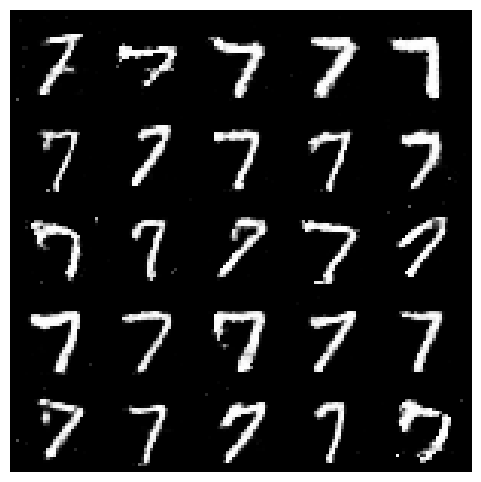

In [9]:
import torch
import numpy as np
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

# Load trained generator
generator.load_state_dict(torch.load('generator_weights.pth'))
generator.eval()

# Sampling parameters
n_samples = 25  # number of images you want
latent_dim = 128  # match your model's latent_dim
target_class = 7  # change this to the class you want to sample

# Generate fixed labels
gen_labels = torch.full((n_samples,), target_class, dtype=torch.long)

# Sample noise
z = torch.randn(n_samples, latent_dim)

# Move to GPU if needed
z = z.cuda() if torch.cuda.is_available() else z
gen_labels = gen_labels.cuda() if torch.cuda.is_available() else gen_labels
generator = generator.cuda() if torch.cuda.is_available() else generator

# Generate images
with torch.no_grad():
    gen_imgs = generator(z, gen_labels)

grid = make_grid(
    gen_imgs.cpu(),
    nrow=5,
    normalize=True,
    value_range=(-1, 1)
)

np_grid = grid.permute(1, 2, 0).numpy()

plt.figure(figsize=(6, 6))
plt.imshow(np_grid)
plt.axis("off")
plt.show()

